<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week15/Day5/DailyChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center"> Credit Fraud Detector </h1>

<h2> Introduction </h2>
In this kernel we will use various predictive models to see how accurate they  are in detecting whether a transaction is a normal payment or a fraud. As described in the dataset, the features are scaled and the names of the features are not shown due to privacy reasons. Nevertheless, we can still analyze some important aspects of the dataset. Let's start!


<h2> Our Goals: </h2>
<ul>
<li> Understand the little distribution of the "little" data that was provided to us. </li>
<li> Create a 50/50 sub-dataframe ratio of "Fraud" and "Non-Fraud" transactions. (NearMiss Algorithm) </li>



<h2> Outline: </h2>
I. <b>Understanding our data</b><br>
a) [Gather Sense of our data](#gather)<br><br>

II. <b>Preprocessing</b><br>
a) [Scaling and Distributing](#distributing)<br>
b) [Splitting the Data](#splitting)<br><br>

III. <b>Random UnderSampling and Oversampling</b><br>
a) [Distributing and Correlating](#correlating)<br>
b) [Anomaly Detection](#anomaly)<br>


## Gather Sense of Our Data:
<a id="gather"></a>
The first thing we must do is gather a <b> basic sense </b> of our data. Remember, except for the <b>transaction</b> and <b>amount</b> we dont know what the other columns are (due to privacy reasons). The only thing we know, is that those columns that are unknown have been scaled already.   

<h3> Summary: </h3>
<ul>
<li>The transaction amount is relatively <b>small</b>. The mean of all the mounts made is approximately USD 88. </li>
<li>There are no <b>"Null"</b> values, so we don't have to work on ways to replace values. </li>
<li> Most of the transactions were <b>Non-Fraud</b> (99.83%) of the time, while <b>Fraud</b> transactions occurs (017%) of the time in the dataframe. </li>
</ul>

<h3> Feature Technicalities: </h3>
<ul>
<li> <b>PCA Transformation: </b>  The description of the data says that all the features went through a PCA transformation (Dimensionality Reduction technique) (Except for time and amount).</li>
<li> <b>Scaling:</b> Keep in mind that in order to implement a PCA transformation features need to be previously scaled. (In this case, all the V features have been scaled or at least that is what we are assuming the people that develop the dataset did.)</li>
</ul>

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import collections
import warnings
warnings.filterwarnings("ignore")

# Machine-learning libraries
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    accuracy_score, classification_report
)

# Imbalanced-data libraries
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced

from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Import the dataset supplied with the Daily Challenge.
#
# In Google Colab, upload:
# "Credit Card Fraud Detection.zip"
#
# The ZIP contains creditcard.csv.

from google.colab import files
import zipfile
import os
import glob

uploaded = files.upload()
uploaded_file = list(uploaded.keys())[0]

extract_dir = "/content/credit_card_fraud_data"
os.makedirs(extract_dir, exist_ok=True)

if uploaded_file.lower().endswith(".zip"):
    with zipfile.ZipFile(uploaded_file, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    csv_files = glob.glob(
        os.path.join(extract_dir, "**", "*.csv"),
        recursive=True
    )

    if not csv_files:
        raise FileNotFoundError("No CSV file was found inside the ZIP.")

    data_path = csv_files[0]

elif uploaded_file.lower().endswith(".csv"):
    data_path = uploaded_file

else:
    raise ValueError("Please upload the project ZIP or creditcard.csv.")

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("File:", data_path)
print("Shape:", df.shape)

display(df.head())

Saving Credit Card Fraud Detection.zip to Credit Card Fraud Detection.zip
Dataset loaded successfully.
File: /content/credit_card_fraud_data/creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Describe the data.

print("Dataset information:")
print("-" * 60)
df.info()

print("\nNumerical summary:")
display(df.describe().T)

print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset information:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19 

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
# Check for missing values.

missing_values = df.isnull().sum()

print("Missing values by column:")
display(missing_values[missing_values > 0])

print("Total missing values:", missing_values.sum())

if missing_values.sum() == 0:
    print("Conclusion: There are no missing values in the dataset.")

Missing values by column:


,0


Total missing values: 0
Conclusion: There are no missing values in the dataset.


In [5]:
# Check whether the target classes are imbalanced.

class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(class_distribution)

print(
    f"Non-fraud transactions (Class 0): "
    f"{class_counts[0]:,} ({class_percentages[0]:.2f}%)"
)
print(
    f"Fraud transactions (Class 1): "
    f"{class_counts[1]:,} ({class_percentages[1]:.2f}%)"
)

print("\nConclusion: The classes are extremely imbalanced.")

,Count,Percentage
Class,,
0,284315,99.827251
1,492,0.172749


Non-fraud transactions (Class 0): 284,315 (99.83%)
Fraud transactions (Class 1): 492 (0.17%)

Conclusion: The classes are extremely imbalanced.


### Answer — Are the classes skewed?

Yes. The original dataset is **extremely imbalanced**.

It contains approximately:

- **284,315 non-fraud transactions (99.83%)**
- **492 fraud transactions (0.17%)**

This is important because a model could obtain very high accuracy by predicting almost every transaction as non-fraud, while still failing to detect the rare fraudulent cases. For an imbalanced problem like this, metrics such as **precision, recall, F1-score and ROC-AUC** are generally more informative than accuracy alone.

In [6]:

print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


**Note:**  Notice how imbalanced is our original dataset! Most of the transactions are non-fraud. If we use this dataframe as the base for our predictive models and analysis we might get a lot of errors and our algorithms will probably overfit since it will "assume" that most transactions are not fraud. But we don't want our model to assume, we want our model to detect patterns that give signs of fraud!

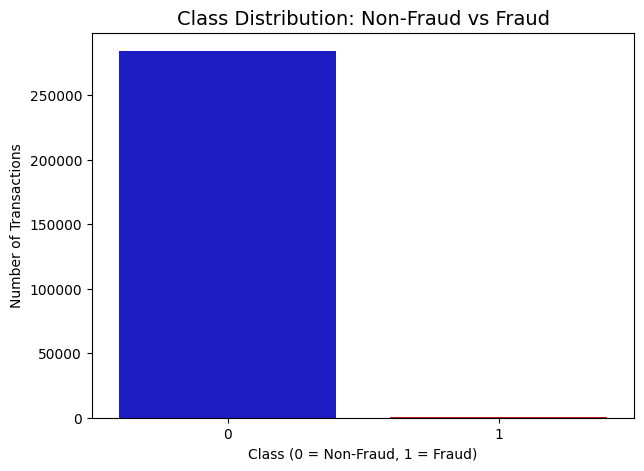

In [7]:
# Visualize the original class imbalance.

colors = ["#0101DF", "#DF0101"]

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Class",
    data=df,
    palette=colors
)

plt.title("Class Distribution: Non-Fraud vs Fraud", fontsize=14)
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

**Distributions:** By seeing the distributions we can have an idea how skewed are these features, we can also see further distributions of the other features. There are techniques that can help the distributions be less skewed which will be implemented in this notebook in the future.

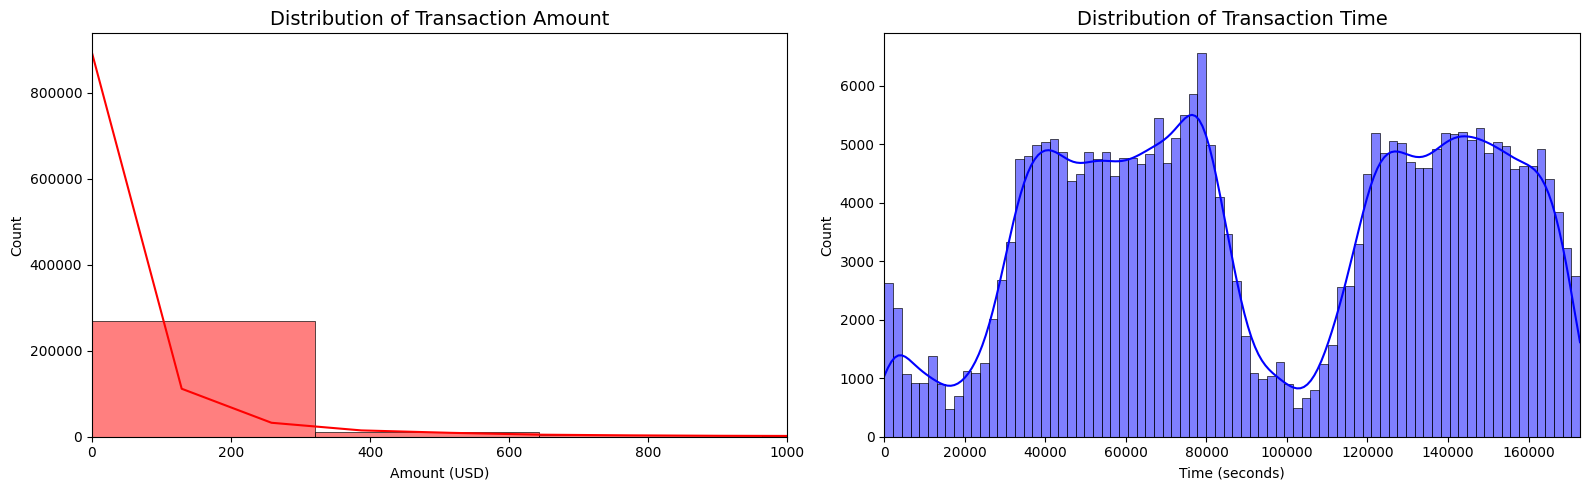

In [8]:
# Plot the distributions of transaction Amount and Time side by side.

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    df["Amount"],
    bins=80,
    kde=True,
    ax=ax[0],
    color="r"
)
ax[0].set_title("Distribution of Transaction Amount", fontsize=14)
ax[0].set_xlim(0, 1000)
ax[0].set_xlabel("Amount (USD)")

sns.histplot(
    df["Time"],
    bins=80,
    kde=True,
    ax=ax[1],
    color="b"
)
ax[1].set_title("Distribution of Transaction Time", fontsize=14)
ax[1].set_xlim(df["Time"].min(), df["Time"].max())
ax[1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

### Distribution observations

The transaction amount distribution is strongly right-skewed: most transactions are relatively small, while a small number have very large amounts.

The `Time` variable spans the full observation period and is not on the same numerical scale as the PCA-transformed `V1`–`V28` features. This is why `Time` and `Amount` are scaled before further analysis.

<h2> Scaling and Distributing </h2>
<a id="distributing"></a>
In this phase of our kernel, we will first scale the columns comprise of <b>Time</b> and <b>Amount </b>. Time and amount should be scaled as the other columns. On the other hand, we need to also create a sub sample of the dataframe in order to have an equal amount of Fraud and Non-Fraud cases, helping our algorithms better understand patterns that determines whether a transaction is a fraud or not.

<h3> What is a sub-Sample?</h3>
In this scenario, our subsample will be a dataframe with a 50/50 ratio of fraud and non-fraud transactions. Meaning our sub-sample will have the same amount of fraud and non fraud transactions.

<h3> Why do we create a sub-Sample?</h3>
In the beginning of this notebook we saw that the original dataframe was heavily imbalanced! Using the original dataframe  will cause the following issues:
<ul>
<li><b>Overfitting: </b>Our classification models will assume that in most cases there are no frauds! What we want for our model is to be certain when a fraud occurs. </li>
<li><b>Wrong Correlations:</b> Although we don't know what the "V" features stand for, it will be useful to understand how each of this features influence the result (Fraud or No Fraud) by having an imbalance dataframe we are not able to see the true correlations between the class and features. </li>
</ul>

<h3>Summary: </h3>
<ul>
<li> <b>Scaled amount </b> and <b> scaled time </b> are the columns with scaled values. </li>
<li> There are <b>492 cases </b> of fraud in our dataset so we can randomly get 492 cases of non-fraud to create our new sub dataframe. </li>
<li>We concat the 492 cases of fraud and non fraud, <b>creating a new sub-sample. </b></li>
</ul>

In [9]:
# Scale Amount and Time using RobustScaler.
#
# RobustScaler is useful here because it uses the median and interquartile
# range, making it less sensitive to extreme outliers than StandardScaler.

rob_scaler = RobustScaler()

df["scaled_amount"] = rob_scaler.fit_transform(
    df["Amount"].values.reshape(-1, 1)
)

df["scaled_time"] = rob_scaler.fit_transform(
    df["Time"].values.reshape(-1, 1)
)

# Remove the original unscaled columns.
df.drop(["Time", "Amount"], axis=1, inplace=True)

display(df.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


In [10]:
# Reorder the dataframe so scaled_amount and scaled_time appear first.

scaled_amount = df["scaled_amount"]
scaled_time = df["scaled_time"]

df.drop(["scaled_amount", "scaled_time"], axis=1, inplace=True)

df.insert(0, "scaled_amount", scaled_amount)
df.insert(1, "scaled_time", scaled_time)

print("First columns:", df.columns[:5].tolist())
display(df.head())

First columns: ['scaled_amount', 'scaled_time', 'V1', 'V2', 'V3']


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


### Splitting the Data (Original DataFrame)
<a id="splitting"></a>
Before proceeding with the <b> Random UnderSampling technique</b> we have to separate the orginal dataframe. <b> Why? for testing purposes, remember although we are splitting the data when implementing Random UnderSampling or OverSampling techniques, we want to test our models on the original testing set not on the testing set created by either of these techniques.</b> The main goal is to fit the model either with the dataframes that were undersample and oversample (in order for our models to detect the patterns), and test it on the original testing set.  

In [11]:
# 1. Print the class percentages in the full dataset.

print(
    "No Frauds:",
    round(df["Class"].value_counts()[0] / len(df) * 100, 2),
    "% of the dataset"
)

print(
    "Frauds:",
    round(df["Class"].value_counts()[1] / len(df) * 100, 2),
    "% of the dataset"
)

# 2. Separate features (X) from the target (y).

X = df.drop("Class", axis=1)
y = df["Class"]

# 3. Use StratifiedKFold so each split keeps approximately the same
# fraud/non-fraud proportions as the original dataset.

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, test_index) in enumerate(
    stratified_kfold.split(X, y),
    start=1
):
    print(f"Fold {fold}")
    print("Train indices:", train_index[:10], "...")
    print("Test indices: ", test_index[:10], "...")
    print("-" * 60)

# 4. Create a separate stratified 80/20 hold-out split.
# This original testing set should be preserved for later model evaluation.

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the distribution before converting to NumPy arrays.
train_counts_label = original_ytrain.value_counts(normalize=False).sort_index()
test_counts_label = original_ytest.value_counts(normalize=False).sort_index()

print("\nTraining-label proportions:")
print(train_counts_label / len(original_ytrain))

print("\nTesting-label proportions:")
print(test_counts_label / len(original_ytest))

# Turn into NumPy arrays, matching the structure of the original notebook.
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

print("\nFinal array shapes:")
print("original_Xtrain:", original_Xtrain.shape)
print("original_Xtest: ", original_Xtest.shape)
print("original_ytrain:", original_ytrain.shape)
print("original_ytest: ", original_ytest.shape)

No Frauds: 99.83 % of the dataset
Frauds: 0.17 % of the dataset
Fold 1
Train indices: [ 0  1  2  3  4  6  8 11 12 13] ...
Test indices:  [ 5  7  9 10 16 18 21 35 49 52] ...
------------------------------------------------------------
Fold 2
Train indices: [ 0  3  4  5  6  7  8  9 10 11] ...
Test indices:  [ 1  2 13 17 23 28 32 38 41 44] ...
------------------------------------------------------------
Fold 3
Train indices: [ 1  2  5  7  9 10 11 13 14 15] ...
Test indices:  [ 0  3  4  6  8 12 20 30 31 34] ...
------------------------------------------------------------
Fold 4
Train indices: [0 1 2 3 4 5 6 7 8 9] ...
Test indices:  [14 19 27 33 37 39 40 43 45 51] ...
------------------------------------------------------------
Fold 5
Train indices: [0 1 2 3 4 5 6 7 8 9] ...
Test indices:  [11 15 22 24 25 26 29 36 46 48] ...
------------------------------------------------------------

Training-label proportions:
Class
0    0.998271
1    0.001729
Name: count, dtype: float64

Testing-label 

## Random Under-Sampling:
<img src="http://contrib.scikit-learn.org/imbalanced-learn/stable/_images/sphx_glr_plot_random_under_sampler_001.png">

In this phase of the project we will implement *"Random Under Sampling"* which basically consists of removing data in order to have a more <b> balanced dataset </b> and thus avoiding our models to overfitting.

#### Steps:
<ul>
<li>The first thing we have to do is determine how <b>imbalanced</b> is our class (use "value_counts()" on the class column to determine the amount for each label)  </li>
<li>Once we determine how many instances are considered <b>fraud transactions </b> (Fraud = "1") , we should bring the <b>non-fraud transactions</b> to the same amount as fraud transactions (assuming we want a 50/50 ratio), this will be equivalent to 492 cases of fraud and 492 cases of non-fraud transactions.  </li>
<li> After implementing this technique, we have a sub-sample of our dataframe with a 50/50 ratio with regards to our classes. Then the next step we will implement is to <b>shuffle the data</b> to see if our models can maintain a certain accuracy everytime we run this script.</li>
</ul>

**Note:** The main issue with "Random Under-Sampling" is that we run the risk that our classification models will not perform as accurate as we would like to since there is a great deal of <b>information loss</b> (bringing 492 non-fraud transaction  from 284,315 non-fraud transaction)

In [12]:
# Since our classes are highly skewed, create a balanced 50/50 subsample
# using Random Under-Sampling.

# Shuffle the full dataset first.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Number of fraudulent transactions in the dataset.
fraud_count = df["Class"].value_counts()[1]
print("Number of fraud transactions:", fraud_count)

# Keep all fraud cases.
fraud_df = df.loc[df["Class"] == 1]

# Randomly sample the same number of non-fraud cases.
non_fraud_df = (
    df.loc[df["Class"] == 0]
      .sample(n=fraud_count, random_state=42)
)

# Combine both classes.
normal_distributed_df = pd.concat(
    [fraud_df, non_fraud_df],
    axis=0
)

# Shuffle the balanced dataframe.
new_df = normal_distributed_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced subsample shape:", new_df.shape)
display(new_df.head())

Number of fraud transactions: 492
Balanced subsample shape: (984, 31)


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,-0.279466,0.996558,-0.300026,0.949818,0.074290,0.933936,0.996314,-0.734827,1.065931,-0.046607,...,0.004937,0.166577,0.660828,-0.253749,-0.004951,-0.059794,-0.392513,0.422035,0.234143,0
1,18.615944,-0.226824,-2.923827,1.524837,-3.018758,3.289291,-5.755542,2.218276,-0.509995,-3.569444,...,-0.447039,-0.511657,-0.122724,-4.288639,0.563797,-0.949451,-0.204532,1.510206,-0.324706,1
2,2.586460,-0.353435,0.786116,-1.067510,0.917200,0.885069,-0.987685,0.989969,-0.692766,0.296164,...,0.365800,0.141353,0.412901,-0.432923,-0.366233,0.546041,0.702749,-0.008153,0.037743,0
3,2.080905,-0.335930,-1.229669,1.956099,-0.851198,2.796987,-1.913977,-0.044934,-1.340739,-0.555548,...,0.270459,1.208054,0.277612,0.019266,0.508529,-0.201183,-0.249600,0.562239,0.075309,1
4,-0.296653,0.852830,-0.242245,4.147186,-5.672349,6.493741,1.591168,-1.602523,-0.950463,0.722903,...,0.562030,0.249023,-0.480286,-0.286080,-1.153575,-0.035571,0.559628,0.409446,0.221048,1


##  Equally Distributing and Correlating:
<a id="correlating"></a>
Now that we have our dataframe correctly balanced, we can go further with our <b>analysis</b> and <b>data preprocessing</b>.

Distribution of the classes in the balanced subsample:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64


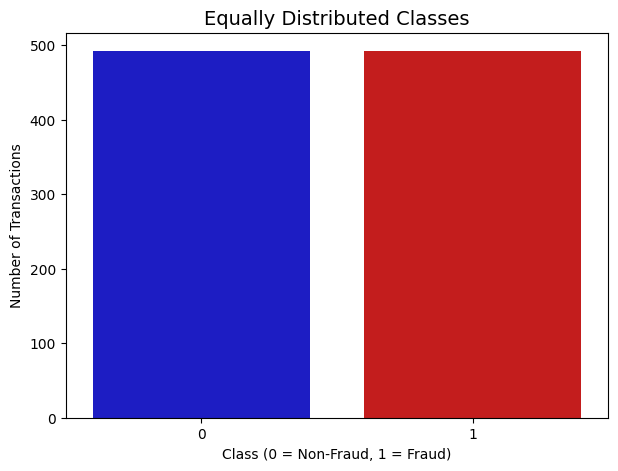

In [13]:
# Print the distribution of the balanced subsample as proportions.

print("Distribution of the classes in the balanced subsample:")
print(new_df["Class"].value_counts(normalize=True).sort_index())

# Visualize the balanced classes.

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Class",
    data=new_df,
    palette=colors
)

plt.title("Equally Distributed Classes", fontsize=14)
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

### Answer — What did Random Under-Sampling change?

The balanced subsample contains the same number of observations from each class:

- **492 fraud transactions**
- **492 non-fraud transactions**

This gives a **50/50 class distribution**, which makes it easier to study patterns and correlations associated with fraud.

The trade-off is information loss: the original dataset contains hundreds of thousands of legitimate transactions, but only 492 of them are retained in this undersampled training subset. For that reason, the original stratified test set should still be used when evaluating a model.

<h3> Correlation Matrices </h3>
Correlation matrices are the essence of understanding our data. We want to know if there are features that influence heavily in whether a specific transaction is a fraud. However, it is important that we use the correct dataframe (subsample)  in order for us to see which features have a high positive or negative correlation with regards to fraud transactions.

### Summary and Explanation:
<ul>
<li><b>Negative Correlations: </b>V17, V14, V12 and V10 are negatively correlated. Notice how the lower these values are, the more likely the end result will be a fraud transaction.  </li>
<li> <b> Positive Correlations: </b> V2, V4, V11, and V19 are positively correlated. Notice how the higher these values are, the more likely the end result will be a fraud transaction. </li>
<li> <b>BoxPlots: </b>  We will use boxplots to have a better understanding of the distribution of these features in fradulent and non fradulent transactions. </li>
</ul>


**Note: ** We have to make sure we use the subsample in our correlation matrix or else our correlation matrix will be affected by the high imbalance between our classes. This occurs due to the high class imbalance in the original dataframe.

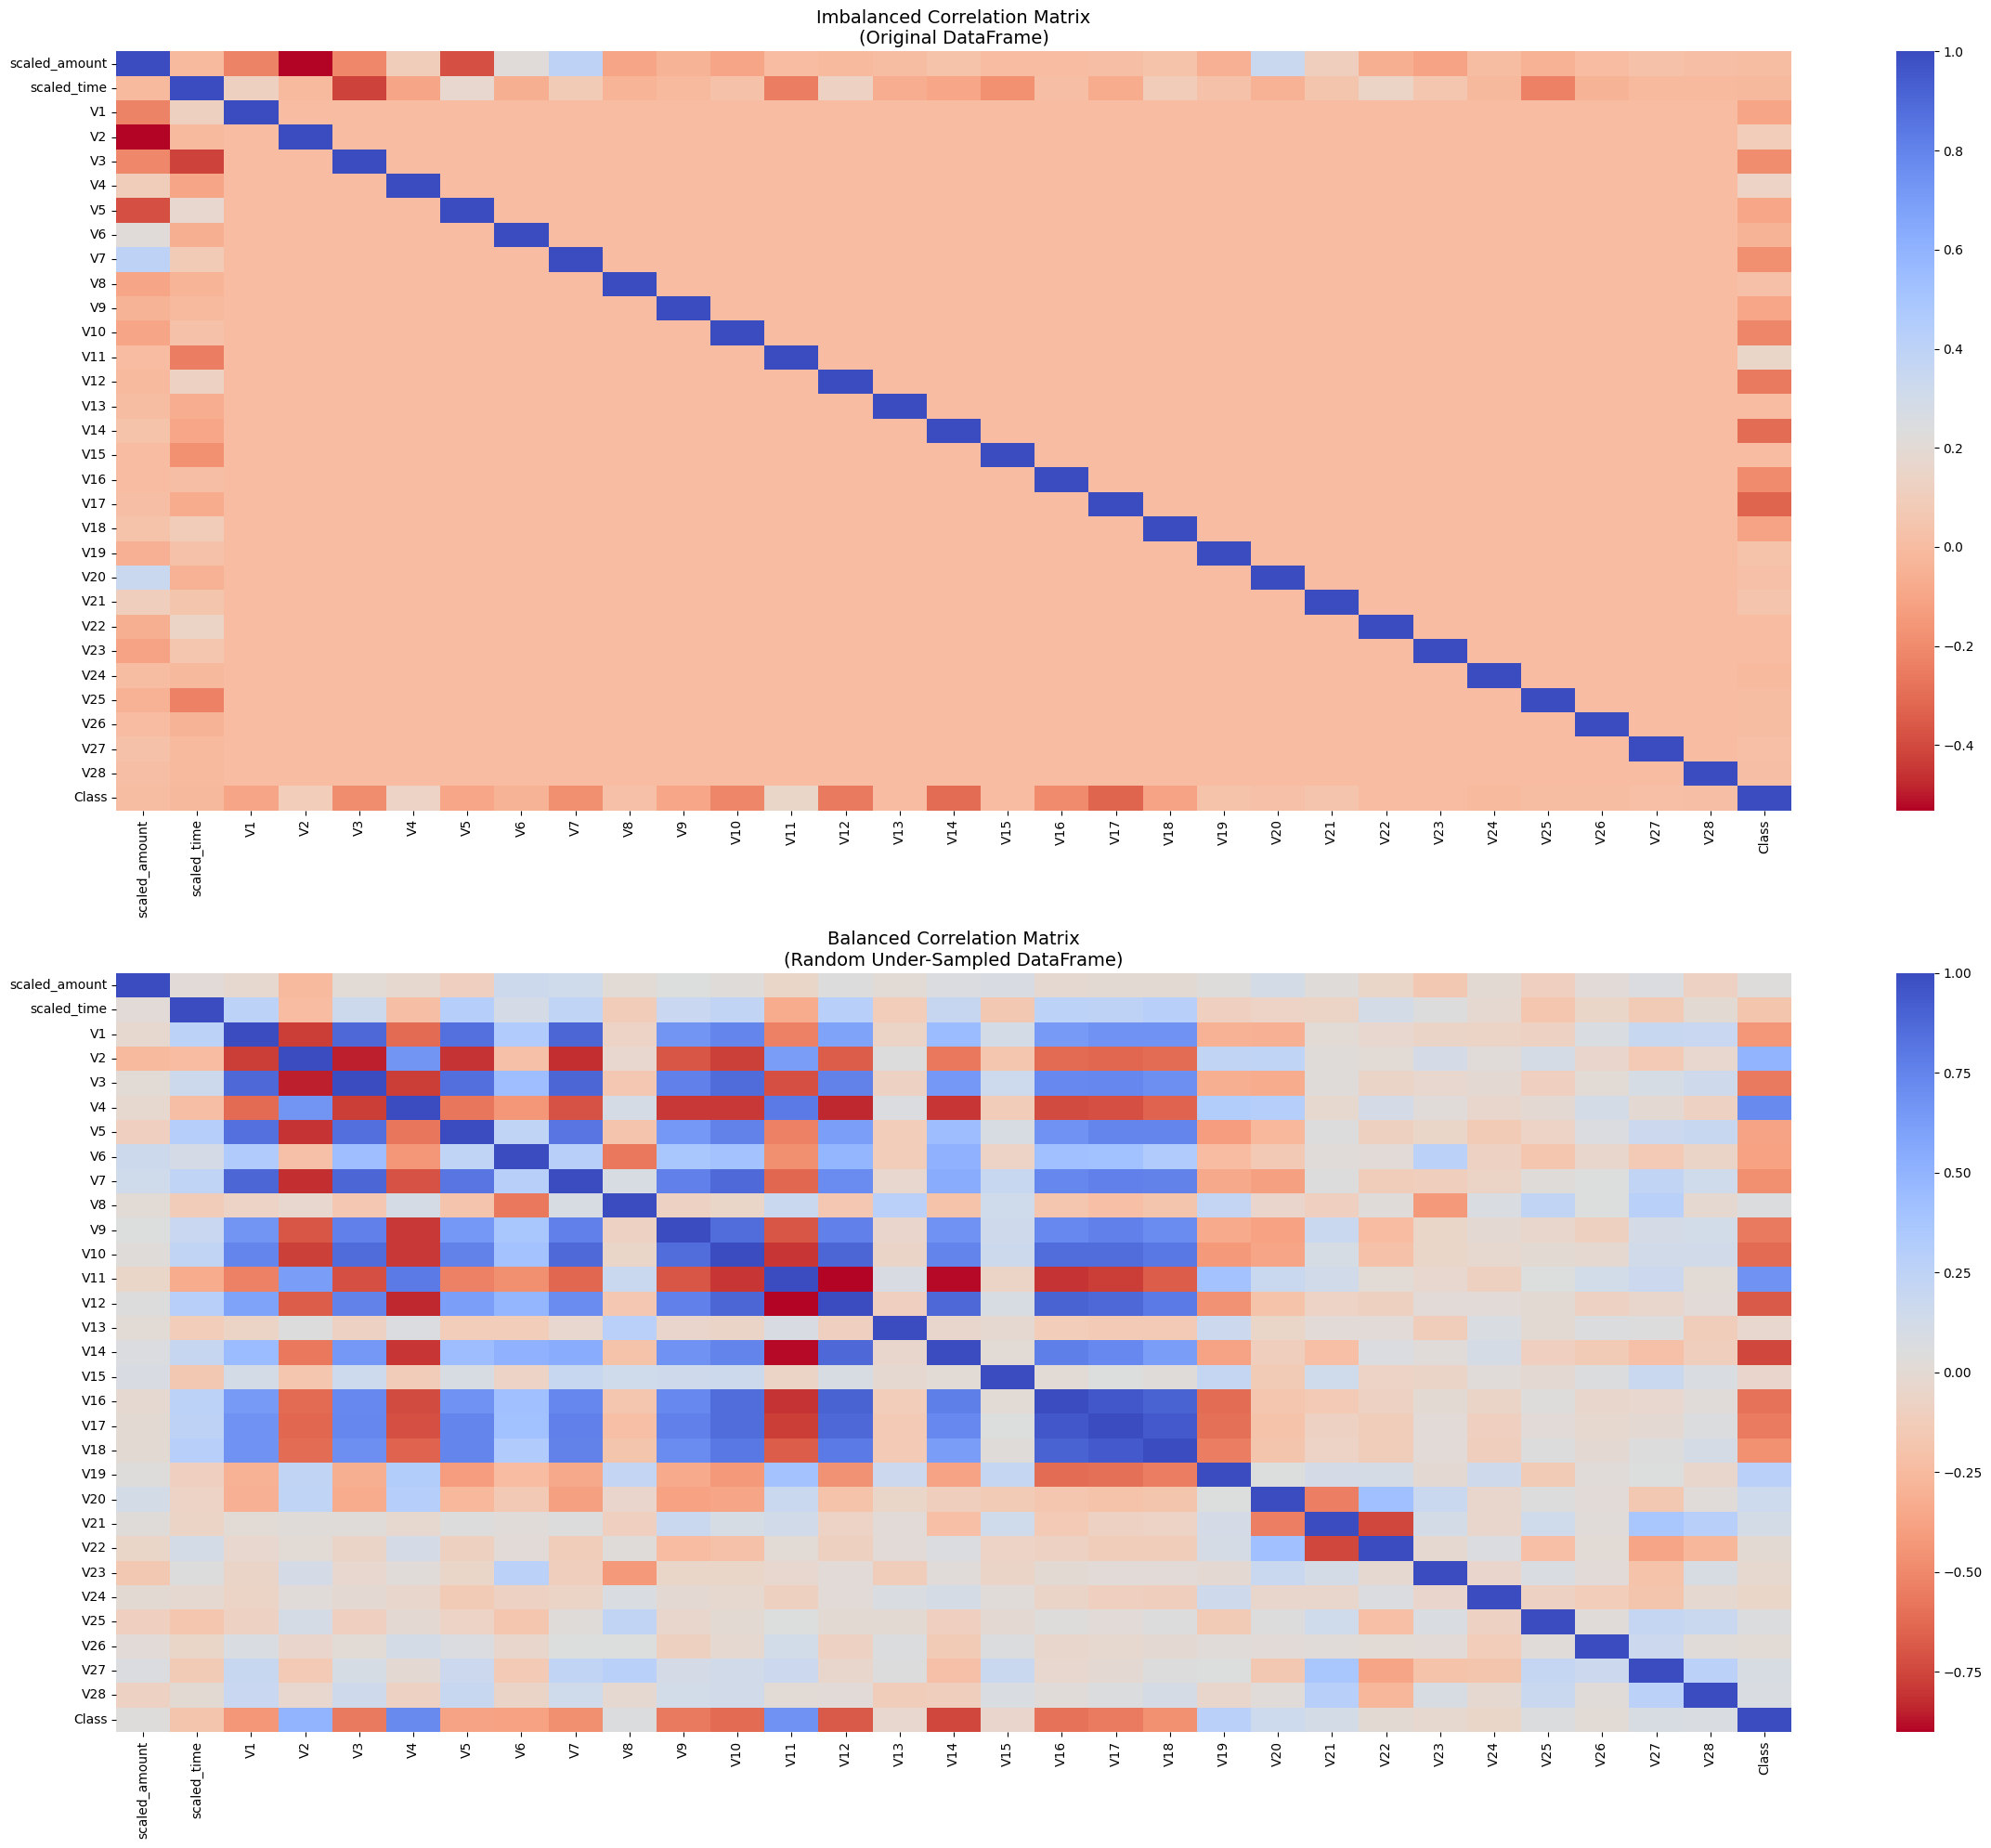

In [14]:
# Compare the correlation matrix of the full imbalanced dataframe
# with the balanced subsample.

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 20))

# Entire DataFrame
corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm_r",
    ax=ax1
)

ax1.set_title(
    "Imbalanced Correlation Matrix\n(Original DataFrame)",
    fontsize=14
)

# Balanced subsample
sub_sample_corr = new_df.corr()

sns.heatmap(
    sub_sample_corr,
    cmap="coolwarm_r",
    ax=ax2
)

ax2.set_title(
    "Balanced Correlation Matrix\n(Random Under-Sampled DataFrame)",
    fontsize=14
)

plt.tight_layout()
plt.show()

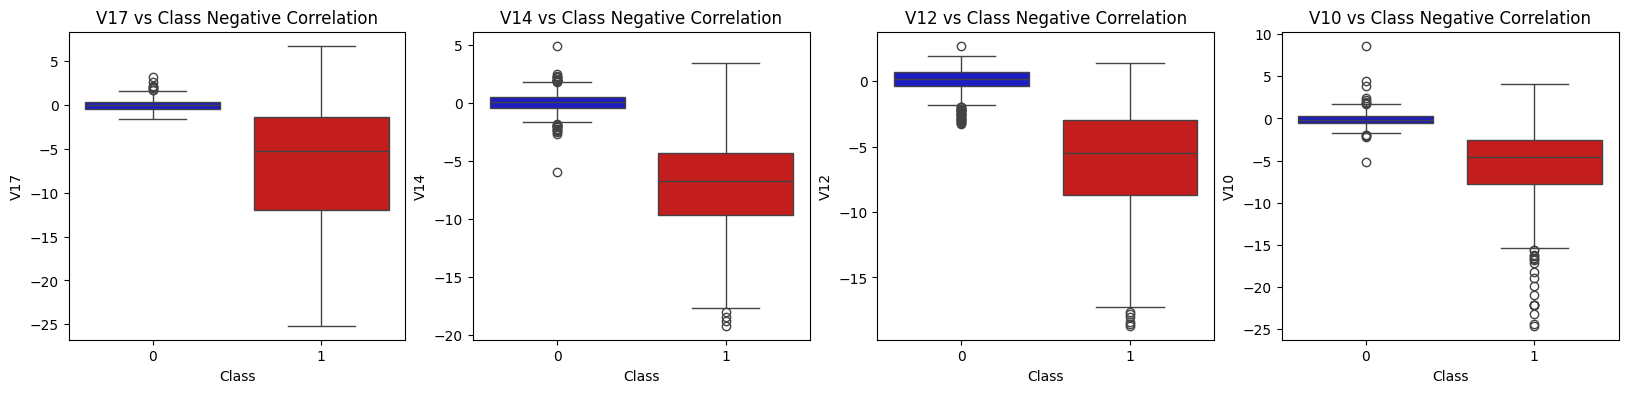

In [15]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)
sns.boxplot(x="Class", y="V17", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')


sns.boxplot(x="Class", y="V10", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

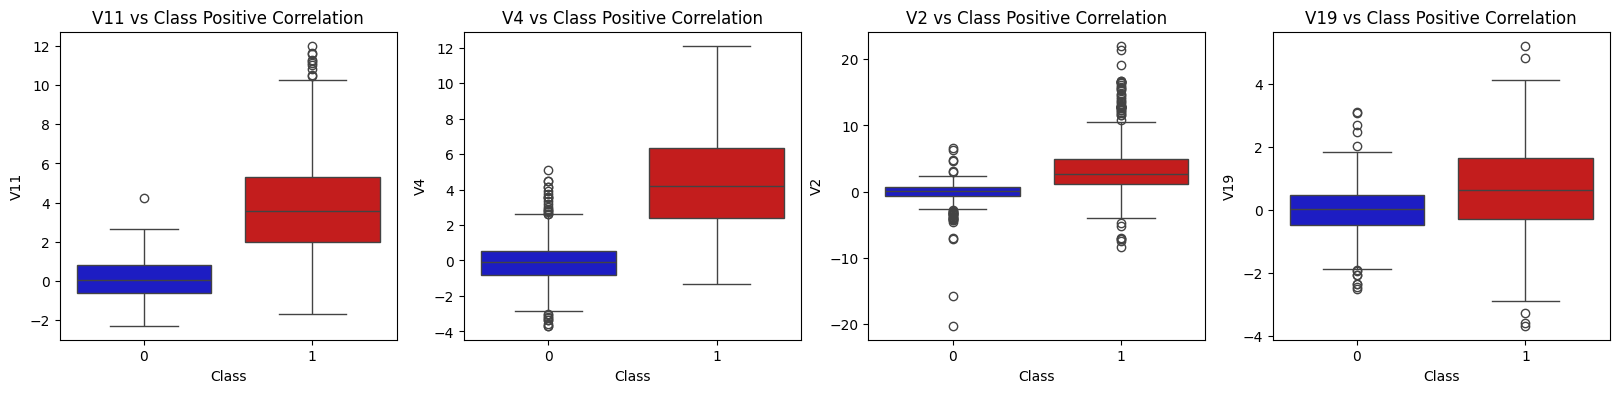

In [16]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')


sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.show()

## Final Takeaways

1. The credit-card fraud dataset contains **284,807 transactions** and has **no missing values**.
2. Fraud is extremely rare: only **492 transactions (about 0.17%)** are fraudulent.
3. `Time` and `Amount` are scaled with `RobustScaler` because the other anonymized `V` features are already transformed/scaled.
4. A stratified train/test split preserves the original class proportions for reliable final evaluation.
5. Random Under-Sampling produces a balanced dataset of **984 observations** (492 fraud + 492 non-fraud), helping us explore fraud-related patterns.
6. The balanced correlation matrix makes the relationships with the target easier to inspect. In the supplied notebook, features such as **V17, V14, V12 and V10** show strong negative relationships with fraud, while **V2, V4, V11 and V19** show positive relationships.
7. The main limitation of undersampling is the large amount of legitimate-transaction data that is discarded. This is why techniques such as **SMOTE/oversampling** can also be useful when building models for imbalanced datasets.